# Пайплайны для обучения LLM: pretrain и SFT

В проекте реализуется pretrain и posttrain этапы обучения LLM.

# 1. Этап Pretrain

## 1.1 Данные

In [1]:
import requests
from datasets import load_dataset

files = requests.get("https://api.github.com/repos/JoannaBy/RussianNovels/contents/corpus?ref=master").json()

/home/ubuntu/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
urls = [
    f["download_url"]
    for f in files
    if f["type"] == "file" and f["name"].endswith(".txt")
]

dataset = load_dataset(
    "text",
    data_files=urls,
    sample_by="document"
)

In [3]:
# проверим, что докуметы уникальны
len(set(urls)) == len(urls)

True

In [4]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 108
    })
})

In [5]:
# пример текста из датасета
print(dataset['train'][0]['text'][:1000])


                                 Посвящается Любови Евгеньевне Белозерской



                             Пошел мелкий снег и вдруг  повалил  хлопьями.
                          Ветер завыл; сделалась метель. В одно  мгновение
                          темное  небо  смешалось  с  снежным  морем.  Все
                          исчезло.
                             - Ну, барин, - закричал ямщик, - беда: буран!
                                                       "Капитанская дочка"

                             И судимы были мертвые по написанному в книгах
                          сообразно с делами своими...



ЧАСТЬ ПЕРВАЯ



1


   Велик был год и страшен год по рождестве Христовом 1918, от  начала  же
революции второй. Был он обилен летом солнцем, а зимою снегом, и  особенно
высоко в небе стояли две звезды: звезда пастушеская -  вечерняя  Венера  и
красный, дрожащий Марс.
   Но дни и в мирные и в кровавые годы летят как стрела, и молодые Турбины
не заметили, как в крепком морозе

## 1.2 Препроцессинг данных

### 1.2.1 Базовая очистка

In [6]:
import re
import unicodedata

import re
import unicodedata

import re
import unicodedata

def clean_text(text: str) -> str:
    if not text:
        return ""

    bad_letter_re     = re.compile(r"[^\W\d_А-Яа-яЁё]")   # любая буква НЕ из RU набора
    repeat_punct_re   = re.compile(r"([,;:!?—\-])\1+")    # "!!!"->"!", "--"->"-"
    many_newlines_re  = re.compile(r"\n{3,}")             # 3+ \n -> "\n\n"
    spaces_re         = re.compile(r"[ \t]+")             # пробелы/табы -> один пробел

    t = unicodedata.normalize("NFC", text).replace("\ufeff", "").replace("\xa0", " ")
    t = t.replace("\r\n", "\n").replace("\r", "\n")

    t = many_newlines_re.sub("\n\n", t).strip()           # приводим к абзацам \n\n
    t = re.sub(r"(?<!\n)\n(?!\n)", " ", t)                # одиночные \n внутри абзаца -> пробел (выравниваем "стихи")

    # чистим пробелы уже в "плоском" тексте
    t = "\n\n".join(spaces_re.sub(" ", p).strip() for p in t.split("\n\n"))

    t = re.sub(r"\.{4,}", "...", t)                       # "...." -> "..."
    t = repeat_punct_re.sub(r"\1", t)

    out_pars = []
    for p in (p.strip() for p in t.split("\n\n")):
        if not p:
            continue
        sentences = re.split(r"(?<=[.!?])\s+", p)          # split на предложения по .!? + пробелы
        kept = [s.strip() for s in sentences if s.strip() and not bad_letter_re.search(s)]
        if kept:
            out_pars.append(" ".join(kept))

    return "\n\n".join(out_pars)

In [7]:
clean_dataset = dataset["train"].map(lambda x: {"text": clean_text(x["text"])})

### 1.2.2 Абзацы как чанки

Есть гипотеза, что в качестве чанков для претрейна можно использовать абзацы: они обычно являются смысловыми единицами, и такая сегментация могла бы помочь модели учиться продолжать текст более связно. Если длина абзаца больше длины чанка, то такой абзац можно на минимально необходимое кол-во чанков. 

В данном разделе разобью текст на абзацы и проанализирую их содержимое.

In [8]:
def to_paragraphs(example, idx):
    paragraphs = [p.strip() for p in example["text"].split("\n\n") if p.strip()]
    return {"doc_id": [idx] * len(paragraphs), "text": paragraphs}

paragraphs_ds = clean_dataset.map(
    to_paragraphs,
    with_indices=True,
    batched=False,
    remove_columns=clean_dataset.column_names)

In [9]:
print("*"*10, 'БЫЛО', "*"*10)
print(clean_dataset['text'][0][:500])
print("")
print("*"*10, 'СТАЛО', "*"*10)
print(paragraphs_ds['text'][0][:5])
# print('\n'.join(paragraphs_ds['text'][0][:5]))

********** БЫЛО **********
Посвящается Любови Евгеньевне Белозерской

Пошел мелкий снег и вдруг повалил хлопьями. Ветер завыл; сделалась метель. В одно мгновение темное небо смешалось с снежным морем. Все исчезло. - Ну, барин, - закричал ямщик, - беда: буран! "Капитанская дочка"

И судимы были мертвые по написанному в книгах сообразно с делами своими...

ЧАСТЬ ПЕРВАЯ

1

Велик был год и страшен год по рождестве Христовом 1918, от начала же революции второй. Был он обилен летом солнцем, а зимою снегом, и особенно высоко в 

********** СТАЛО **********
['Посвящается Любови Евгеньевне Белозерской', 'Пошел мелкий снег и вдруг повалил хлопьями. Ветер завыл; сделалась метель. В одно мгновение темное небо смешалось с снежным морем. Все исчезло. - Ну, барин, - закричал ямщик, - беда: буран! "Капитанская дочка"', 'И судимы были мертвые по написанному в книгах сообразно с делами своими...', 'ЧАСТЬ ПЕРВАЯ', '1']


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pars_per_doc = paragraphs_ds["text"]
all_pars = [p for doc_pars in pars_per_doc for p in doc_pars] 

Сколько абзацев в документе:


count    108.000000
mean      39.388889
std       77.649203
min        1.000000
5%         1.000000
25%        2.000000
50%       12.000000
75%       44.250000
95%      135.950000
max      654.000000
dtype: float64

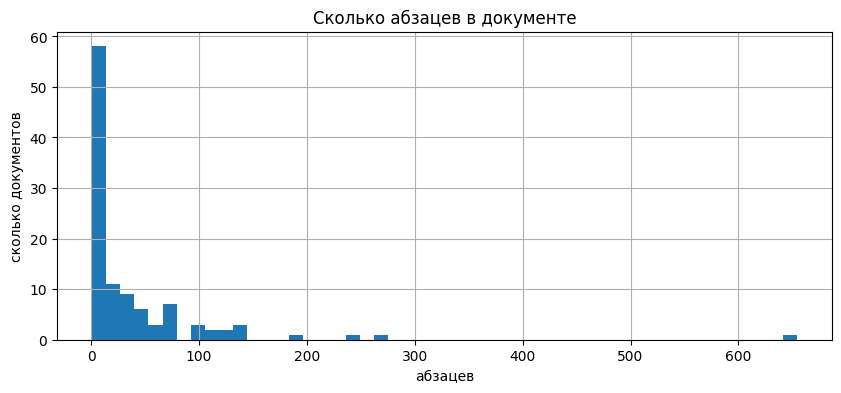

In [11]:
# сколько абзацев в каждом документе
n_pars_per_doc = np.array([len(ps) for ps in pars_per_doc])

print("Сколько абзацев в документе:")
display(pd.Series(n_pars_per_doc).describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))

plt.figure(figsize=(10, 4))
plt.hist(n_pars_per_doc, bins=50)
plt.title("Сколько абзацев в документе")
plt.xlabel("абзацев")
plt.ylabel("сколько документов")
plt.grid()
plt.show()

In [12]:
docs_1_2 = [i for i, ps in enumerate(pars_per_doc) if len(ps) in (1, 2)]
print(f"Документов с 1–2 абзацами: {len(docs_1_2)} ({len(docs_1_2)/len(pars_per_doc)*100:.2f}%)")

Документов с 1–2 абзацами: 29 (26.85%)


In [15]:
# Длины абзацев

lens = np.array([len(p) for p in all_pars])
pd.DataFrame(lens).describe()

,0
count,4.254000e+03
mean,9.790041e+03
std,3.916580e+04
min,1.000000e+00
25%,1.510000e+02
50%,4.336500e+03
75%,9.254750e+03
max,1.288812e+06


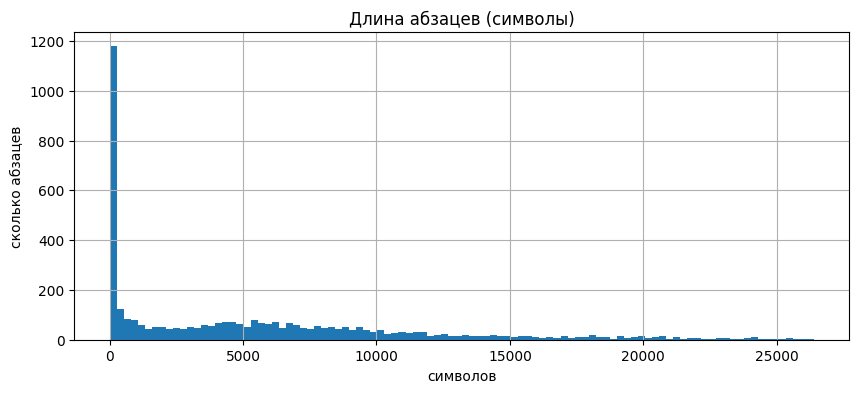

In [16]:
cut = int(np.percentile(lens, 95))

plt.figure(figsize=(10, 4))
counts, edges, _= plt.hist(lens[lens <= cut], bins=100)
plt.title(f"Длина абзацев (символы)")
plt.xlabel("символов")
plt.ylabel("сколько абзацев")
plt.grid()
plt.show()

In [17]:
left, right = edges[0], edges[1]
print(f"Самый левый столбик: [{int(left)}, {int(right)}) символов, абзацев: {int(counts[0])} ({counts[0]/len(lens)})")


Самый левый столбик: [1, 265) символов, абзацев: 1178 (0.2769158439116126)


In [18]:
# Посмотрим примеры коротких абзацев
import random

N = 30
K = 10

short_idx = [i for i, p in enumerate(all_pars) if len(p) < N]
total = len(all_pars)
short_cnt = len(short_idx)
pct = short_cnt / total * 100 if total else 0

print(f"Коротких абзацев (<{N}): {short_cnt} ({pct:.2f}% от всех абзацев)")

random.seed(8)
picked = random.sample(short_idx, k=min(K, len(short_idx)))

for i in picked:
        print(all_pars[i])


Коротких абзацев (<30): 689 (16.20% от всех абзацев)
БАЙ-БАЙ
Только выслужила головушка
НЕЗВАНЫЙ ГОСТЬ
Апреля 25.
ПРИЕХАЛИ В МОНАСТЫРЬ.
2. Продукты производства
Но мне бог возвратит ли все?!
Макаром Девушкиным.
МОРЕ СОЛЕНОЕ И МОРЕ ЗЕЛЕНОЕ
29 апреля


In [19]:
lens_s = pd.Series([len(p) for p in all_pars])
share = (lens_s < 120).mean() * 100
print(f"Доля абзацев короче 120 символов: {share:.2f}%")

Доля абзацев короче 120 символов: 24.07%


In [20]:
# самые частотные
vc = pd.Series(all_pars).value_counts()
display(vc.head(10))

Макар Девушкин.        12
1                       8
* * * * *               6
В. Д.                   5
Часть первая            5
ГЛАВА ПЕРВАЯ            5
Макаром Девушкиным.     4
6                       4
10                      3
5                       3
Name: count, dtype: int64

Я рассматривала вариант формировать обучающие примеры, разделяя текст на абзацы и используя подход "чанк = абзац". После очистки данных (нормализация пробелов и пунктуации, а также удаление предложений с буквами вне современного русского алфавита) разбила корпус на абзацы и проанализировала. 
Выяснилось, что: 
- В 26.85% документов у нас 1-2 формальных абзаца, т.е. часть текста не отформатирована нормально.
- Заметная доля абзацев очень короткие: около 25% имеют длину меньше 120 символов. Если использовать абзацы как чанки, то значительная часть обучающих примеров окажется слишком короткой, а обучение станет менее эффективным (много паддинга и меньше полезных токенов на шаг).

Дополнительно, при ручном просмотре самых коротких абзацев видно, что среди них много служебного "мусора": заголовки глав ("ГЛАВА 1", "ЧАСТЬ ПЕРВАЯ"), одиночные номера, декоративные разделители ("* * * * *"). Такие строки часто повторяются и могут смещать модель в сторону генерации служебных конструкций.

В итоге принято решение отойти от стратегии “чанк = абзац” и перейти к формированию чанков по токенам с фиксированной длиной контекста 512.
При этом на текстовом уровне добавим фильтрацию наиболее типичных служебных вставок (названия глав, их нумерация и т.п.).


### 1.2.3 Доочистка служебных частей

In [21]:
def is_service_paragraph(p, max_heading_len=80):
    s = p.strip()

    # для проверки убираем "обвязку" из не-букв/не-цифр по краям
    s_check = re.sub(r"^[^\wА-Яа-яЁё]+|[^\wА-Яа-яЁё]+$", "", s).strip()

    # только римская цифра (IV, IV., IV))
    if re.fullmatch(r"[IVXLCDM]{1,12}\s*[.)]?\s*", s_check, flags=re.IGNORECASE):
        return True

    # только цифры/символы/пробелы
    if re.fullmatch(r"[\d\W_]+", s_check):
        return True

    # короткий заголовок главы/части/раздела )
    if len(s_check) <= max_heading_len and re.match(r"^(глава|часть|раздел|предисловие|послесловие)\b", s_check, flags=re.IGNORECASE):
        return True

    # нумерованный короткий заголовок: "1. ...", "4) ...", "12. ..."
    if len(s_check) <= max_heading_len and re.match(r"^\d{1,3}\s*[.)]\s+\S+", s_check):
        return True

    return False

In [22]:
to_remove = list(set(p for p in all_pars if is_service_paragraph(p)))

to_remove[:10]

['7',
 'Часть первая',
 '3.',
 '2. Продукты производства',
 'Часть третья 1',
 '39',
 '* ЧАСТЬ ТРЕТЬЯ *',
 'ПРЕДИСЛОВИЕ',
 '2',
 'Часть вторая']

Есть гипотеза, что первые короткие абзацы в текстах также носят служебный характер. Посмотрим на них.

In [23]:
N = 120 

first_pars = [ps[0].strip() for ps in paragraphs_ds["text"] if ps and ps[0].strip()]
first_short = [p for p in first_pars if len(p) < N]

print(f"Коротких первых абзацев (<{N}): {len(first_short)} ({len(first_short)/len(first_pars)*100:.2f}%)")

for p in first_short:
    print("\n", "*"*10)
    print(p)


Коротких первых абзацев (<120): 55 (50.93%)

 **********
Посвящается Любови Евгеньевне Белозерской

 **********
Повесть о том, как близнецы погубили делопроизводителя

 **********
Мастер И Маргарита

 **********
Глава 1. Куррикулюм витэ профессора Персикова

 **********
Михаил Булгаков. Театральный роман * (Записки покойника) *

 **********
Полотенце с петухом

 **********
Антон Павлович Чехов Дама с собачкой Рассказы – 0 Антон Павлович Чехов

 **********
Антон Павлович Чехов Дядя Ваня

 **********
Федор Михайлович Достоевский Бесы

 **********
Федор Михайлович Достоевский Идиот

 **********
РОМАН

 **********
ЧАСТЬ ВТОРАЯ.

 **********
ЧАСТЬ ТРЕТЬЯ.

 **********
ЧАСТЬ ЧЕТВЕРТАЯ.

 **********
Часть первая

 **********
Роман в четырех частях

 **********
Глава первая

 **********
Глава первая

 **********
Часть первая

 **********
ГЛАВА 1

 **********
От станции Себряково до Г-ской станицы.

 **********
Очерк

 **********
отвечала Владимир Набоков Ада, или Радости страсти Семейная хрони

In [24]:
def drop_service_patterns(text: str, to_remove: list[str], first_short=None) -> str:
    if not text:
        return ""

    # сначала вырезаем короткий первый абзац, если текст начинается с него
    for p in first_short:
        s = (p or "").strip()
        if text.lstrip().startswith(s):
            text = text.lstrip()[len(s):]
            text = re.sub(r"^\s*\n{1,}\s*", "", text)  
            break  # одного первого абзаца достаточно
    
    # затем вырезаем все служебные абзацы, которые могут встречаться в любом месте текста
    for p in to_remove:
        s = (p or "").strip()
        if not s:
            continue

        if re.fullmatch(r"\d{1,4}", s):
            text = text.replace(f"\n\n{s}\n\n", "\n\n")
        else:
            text = text.replace(s, "")

    # прибраться
    text = re.sub(r"[ \t]{2,}", " ", text)
    text = re.sub(r"\s+([,.;:!?])", r"\1", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    text = re.sub(r" *\n *", "\n", text).strip()

    return text

In [25]:
clean_dataset = clean_dataset.map(
    lambda x: {"text": drop_service_patterns(x["text"], to_remove, first_short=first_short)}
)

Map: 100%|██████████| 108/108 [00:05<00:00, 20.69 examples/s]


In [26]:
for i, t in enumerate(dataset["train"]["text"][:5], 1):
    print(f"{i}) {t[:100]}")

1) 
                                 Посвящается Любови Евгеньевне Белозерской



                     
2)              Повесть о том, как близнецы погубили делопроизводителя




1. Происшествие 20-го числа

3) Мастер И Маргарита

Михаил Афанасиевич Булгаков
ЧАСТЬ ПЕРВАЯ
 
...Так кто ж ты, наконец?
– Я – часть
4) Глава 1. Куррикулюм витэ профессора Персикова


     16  апреля  1928 года,  вечером, профессор зоол
5) Михаил Булгаков. Театральный роман
* (Записки покойника) * 



ПРЕДИСЛОВИЕ



       Предупреждаю чи


In [27]:
for i, t in enumerate(clean_dataset["text"][:5], 1):
    print(f"{i}) {t[:100]}")

1) Пошел мелкий снег и вдруг повалил хлопьями. Ветер завыл; сделалась метель. В одно мгновение темное н
2) Происшествие 20-го числа

В то время, как все люди скакали с одной службы на другую, товарищ Коротко
3) Михаил Афанасиевич Булгаков...Так кто ж ты, наконец? – Я – часть той силы, что вечно хочет зла и веч
4) Профессор зажег верхний матовый шар и огляделся. Начало ужасающей катастрофы нужно считать заложенны
5) Предупреждаю читателя, что к сочинению этих записок я не имею никакого отношения и достались они мне


## 1.3 Собственный токенизатор

In [ ]:
from tokenizers import (
    decoders,
    models,
    normalizers,
    pre_tokenizers,
    processors,
    trainers,
    Tokenizer,
)
from transformers import PreTrainedTokenizerFast


VOCAB_SIZE = 3000
SPECIAL_TOKENS = ["<pad>", "<bos>", "<eos>", "<unk>"]

tokenizer = Tokenizer(models.BPE(unk_token="<unk>"))
tokenizer.normalizer = normalizers.NFC()

# Изначально пробовала ByteLevel (как в примерах на HF) для BPE-токенизатора, но для кириллицы это дало артефакты в декоде (в генерации появлялись странные символы).
# Поэтому перешла на Metaspace: он дал корректный decode для русских текстов.
tokenizer.pre_tokenizer = pre_tokenizers.Metaspace(replacement="▁")

trainer = trainers.BpeTrainer(
    vocab_size=VOCAB_SIZE,
    special_tokens=SPECIAL_TOKENS,
    show_progress=True
)

In [29]:
def get_training_corpus():
    for i in range(0, len(clean_dataset), 1000):
        yield clean_dataset[i : i + 1000]["text"]

In [30]:
tokenizer.train_from_iterator(get_training_corpus(), trainer=trainer)

In [31]:
tokenizer.decoder = decoders.Metaspace(replacement="▁")

In [32]:
wrapped_tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=tokenizer,
    bos_token="<bos>",
    eos_token="<eos>",
    unk_token="<unk>",
    pad_token="<pad>",
)

In [33]:
print("Vocab size:", wrapped_tokenizer.vocab_size)
print("Special tokens:", wrapped_tokenizer.special_tokens_map)

Vocab size: 3000
Special tokens: {'bos_token': '<bos>', 'eos_token': '<eos>', 'unk_token': '<unk>', 'pad_token': '<pad>'}


In [34]:
s = "Привет, мир!"
enc = wrapped_tokenizer(s, add_special_tokens=False)
print(wrapped_tokenizer.convert_ids_to_tokens(enc["input_ids"])[:30])

['▁При', 'вет', ',', '▁ми', 'р', '!']


In [35]:
wrapped_tokenizer.save_pretrained("tokenizer")

('tokenizer/tokenizer_config.json', 'tokenizer/tokenizer.json')

## 1.4 Токенизация данных 

In [36]:
def tokenize(batch):
    return wrapped_tokenizer(batch["text"], add_special_tokens=False)

tokenized = clean_dataset.map(
    tokenize,
    batched=True,
    remove_columns=clean_dataset.column_names,
)

Map: 100%|██████████| 108/108 [00:09<00:00, 11.08 examples/s]


In [37]:
def train_data_to_chunk(batch, group_size=512):
    bos_id = wrapped_tokenizer.bos_token_id
    eos_id = wrapped_tokenizer.eos_token_id

    input_ids = []
    labels = []

    inner = group_size - 2  

    for ids in batch["input_ids"]:        
        for i in range(0, len(ids), inner):
            chunk = ids[i:i+inner]
            if len(chunk) < inner:
                continue  # хвост выкидываем

            seq = [bos_id] + chunk + [eos_id]
            input_ids.append(seq)
            labels.append(seq.copy())

    return {"input_ids": input_ids, "labels": labels}

In [38]:
chunk_dataset = tokenized.map(
    lambda batch: train_data_to_chunk(batch, group_size=512),
    batched=True,
    remove_columns=tokenized.column_names,  
)

Map:   0%|          | 0/108 [00:00<?, ? examples/s]

Map: 100%|██████████| 108/108 [00:07<00:00, 14.48 examples/s]


In [39]:
ids = chunk_dataset[8]["input_ids"]
decoded = wrapped_tokenizer.decode(ids)

print(decoded[:500])

<bos> позднее, слышите ли, - самое позднее, сегодня в три часа дня, а сейчас уже десять. В молчании вернулись в столовую. Гитара мрачно молчит. Николка из кухни тащит самовар, и тот поет зловеще и плюется. На столе чашки с нежными цветами снаружи и золотые внутри, особенные, в виде фигурных колоннок. При матери, Анне Владимировне, это был праздничный сервиз в семействе, а теперь у детей пошел на каждый день. Скатерть, несмотря на пушки и на все это томление, тревогу и чепуху, бела и крахмальна. 


## 1.5 Инициализация ЛЛМ

In [40]:
from transformers import LlamaConfig, LlamaForCausalLM

config = LlamaConfig(
    vocab_size=wrapped_tokenizer.vocab_size,
    bos_token_id=wrapped_tokenizer.bos_token_id,
    eos_token_id=wrapped_tokenizer.eos_token_id,
    pad_token_id=wrapped_tokenizer.pad_token_id,

    hidden_size=1024,
    intermediate_size=1536,
    num_hidden_layers=16,
    num_attention_heads=16,
    num_key_value_heads=8,

    max_position_embeddings=512,
    rms_norm_eps=1e-6,
    rope_theta=10000.0,
)

model = LlamaForCausalLM(config)
model.config.use_cache = False

In [41]:
n_params = sum(p.numel() for p in model.parameters())
print(f"Params: {n_params/1e6:.1f}M")

Params: 132.0M


## 1.6 Реализация Trainer с коллбэками для валидации качества на промптах

In [42]:
import torch
from transformers import TrainingArguments, Trainer, TrainerCallback

test_prompts = [
    "Все мысли, которые имеют огромные последствия",
    "Сила войска зависит от его духа",
    "Мысль о том, что он принес страдания",
    "Человек сознает себя свободным",
    "Что бы ни случилось, я всегда буду",
    "Любовь мешает смерти",
    "Нет, жизнь не кончена",
    "Всякая мысль, даже самая простая",
    "Война не любезность, а самое гадкое дело",
    "Чтобы жить честно"
]

In [43]:
def data_collator(features):
    input_ids = torch.tensor([f["input_ids"] for f in features], dtype=torch.long)
    labels = torch.tensor([f["labels"] for f in features], dtype=torch.long)
    attention_mask = torch.ones_like(input_ids, dtype=torch.long)
    return {
        "input_ids": input_ids,
        "labels": labels,
        "attention_mask": attention_mask,
    }

In [44]:
class PromptEvalCallback(TrainerCallback):
    def __init__(self, tokenizer, prompts, max_new_tokens=120, every_steps=1000):
        self.tokenizer = tokenizer
        self.prompts = prompts
        self.max_new_tokens = max_new_tokens
        self.every_steps = every_steps

    @torch.no_grad()
    def _generate(self, model, tag: str):
        model.eval()
        dev = next(model.parameters()).device

        print("\n" + "=" * 30)
        print(f"PROMPT EVAL @ {tag}")
        print("=" * 30)

        for p in self.prompts:
            enc = self.tokenizer(p, return_tensors="pt", add_special_tokens=False)
            enc = {k: v.to(dev) for k, v in enc.items()}

            out = model.generate(
                **enc,
                max_new_tokens=self.max_new_tokens,
                do_sample=False, 
                eos_token_id=self.tokenizer.eos_token_id,
                pad_token_id=self.tokenizer.pad_token_id,
            )

            txt = self.tokenizer.decode(out[0], skip_special_tokens=True)
            print("\n---")
            print(txt)

        model.train()

    def on_step_end(self, args, state, control, **kwargs):
        if self.every_steps and state.global_step > 0 and state.global_step % self.every_steps == 0:
            self._generate(kwargs["model"], tag=f"step_{state.global_step}")

    def on_epoch_end(self, args, state, control, **kwargs):
        self._generate(kwargs["model"], tag=f"epoch_{state.epoch}")

In [ ]:
train_args = TrainingArguments(
    output_dir="pretrain_llm",

    per_device_train_batch_size=2,
    gradient_accumulation_steps=32,  
    max_steps=8000,                
    warmup_steps=200,
    learning_rate=2e-4,
    weight_decay=0.1,                
    bf16=False,
    fp16=True,
    logging_steps=50,
    save_steps=500,
    save_total_limit=2,
    report_to="none",
    remove_unused_columns=False,
    max_grad_norm=1.0,
    dataloader_num_workers=2,
    dataloader_pin_memory=True
)

In [46]:
trainer = Trainer(
    model=model,
    args=train_args,
    train_dataset=chunk_dataset,
    data_collator=data_collator,
    callbacks=[PromptEvalCallback(wrapped_tokenizer, test_prompts, max_new_tokens=120, every_steps=1000)],
)

trainer.train()


Step,Training Loss
50,7.551006
100,7.067584
150,6.950704
200,6.404158
250,5.734263
300,5.140813
350,4.757952
400,4.482262
450,4.251190
500,4.132647



PROMPT EVAL @ epoch_1.0

---
Все мысли, которые имеют огромные последствия и невыному; но и не было ни слова; ни в чем ни было ни в чем ни в чем ни в чем ни в чем ни в чем ни в чем ни в чем ни в чем ни в чем ни в чем ни в чем ни влиянии, ни в чем ни влиянии, ни в чем ни влия и не было ни в чем; но в то же не было ни в чем не было ни в чем ни в чем ни в чем ни в чем не было; но в этом не было в том, что в этом не было в том,

---
Сила войска зависит от его духа... - Я не понимаю. - Я не хочу... - Я не хочу... - Я не хочу... - Я не хочу... - Я не хочу... - Я не хочу... - Я не хочу... - Я не хочу... - Я не хочу... - Я не хочу... - Я не хочу... - Я не хочу... - Я не хочу... - Я не хочу... - Я не... - Я не... - Я не... - Я не... - Я... я... я... я не... я... я не... я не... я не... я не... я не... я

---
Мысль о том, что он принес страдания нашей

---
Человек сознает себя свободным и более и более и более и и более и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и и

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.10s/it]



PROMPT EVAL @ epoch_2.0

---
Все мысли, которые имеют огромные последствия исти и несомненности и несомненности и несомненности и несомненности и несомненности и несомненности и несонасти и несонасти и несонасти и несонам истинной истиной истиной истиной истиной истиной истиной истиной истиной истиной истиной истиной истиной истиной истиной истиной истиной истиной истиной истиной и

---
Сила войска зависит от его духа Григорию Григоривъъъъъъъъъъъъъъъъъъъъъъ съъъъ съъъ съъъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ съъ

---
Мысль о том, что он принес страдания к его иму, и что он не может быть иначе. Он не мог понять того, что он не мог понять его. Он не мог не думать о том, что он не мог не думать о том, что он не мог не думать о том, что он не мог не думать о том, что он не мог не думать о том, что он не может не любить его. Он не мог не думать о том, что он не мо

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.08s/it]


...

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.07s/it]



PROMPT EVAL @ epoch_19.0

---
Все мысли, которые имеют огромные последствияновнейских,; козыровскаями и ворочески такуя, телотвнонику какуенк, преждеенечка в видеэров. "Испуганы теодоровского". Ведь это так нашего сердца! Астров сектантов образумировался, бросил его в сумму идеалил, а сам жрел (он блеск глаз Бога выходила на чистую железу крыш, на клеенчатом диважам шлепили и пешеходы надписи

---
Сила войска зависит от его духа. его своих постоян на местока привле?" ухака отца его нагоняла ввербардии порадоминая мать. Поколояны был бусад худой, поисти и растеряно; столь же притворно кламенье,; походкой Павлинок, как и по пощум, грабитечи; и награда за эту сумвенную власть, за то, что мог облагодеянию мою землю потехидом не наскугрыгом из алга

---
Мысль о том, что он принес страдания глубоужу вам... Фокляенъ, ондинлесс... он сам смер еще не пред землеми услых и видел. Он избегал только возвратиш своим только всемил над собою над их горячими ударениями; таким, какого бездну него. "Ива

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.04s/it]



PROMPT EVAL @ epoch_19.27710843373494

---
Все мысли, которые имеют огромные последствияновнейских,; козыровскаями и ворочески такуя, телотвнонику какуенк, преждеенечка в видеэров. "Испуганы теодоровского". Ведь это так нашего сердца! Астров сектантов образумировался, сел на донес, - так-таки и иначе нарастают духа не просто лишь без, а именно, точно, черессеушем она вовсе как бы и не появится. Итак, недавно прочитан другой

---
Сила войска зависит от его духа. его своих постоян на местока привле?" ухака отца его нагоняла наступат свой свойе, было было довольствовать. В последние два часа по случастям, так же употребностя почаще ПосЕему хворомо, стали укрепожили оно все до последствиям. В келье, когда И уже был мастерц, по обедержанисти, говорили о каких-нибудь по тому испуге?.. На каких черта мы могут быть этоби? по всему, стом... "Е

---
Мысль о том, что он принес страдания глубоужу вам... Фокляенъ, ондинлесс... он побыыка его, видел... " отщищиров... Кузькаша! Дюжу от него тут это 

TrainOutput(global_step=8000, training_loss=1.6831120733320712, metrics={'train_runtime': 6596.8116, 'train_samples_per_second': 77.613, 'train_steps_per_second': 1.213, 'total_flos': 2.02797081427968e+17, 'train_loss': 1.6831120733320712, 'epoch': 19.27710843373494})

In [50]:
@torch.no_grad()
def generate_final(model, tokenizer, prompts, max_new_tokens=180):
    model.eval()
    for p in prompts:
        enc = tokenizer(p, return_tensors="pt", add_special_tokens=False).to(model.device)
        out = model.generate(
            **enc,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1,
            no_repeat_ngram_size=3,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.pad_token_id,
        )
        print("\n===")
        print("PROMPT:", p)
        print(tokenizer.decode(out[0], skip_special_tokens=True))

generate_final(model, wrapped_tokenizer, test_prompts, max_new_tokens=180)



===
PROMPT: Все мысли, которые имеют огромные последствия
Все мысли, которые имеют огромные последствияновней-с? хлеб крикнул збанов, белым серновремполцем: загорую Бевея и камыша ше!.. Зеорваю я вас виновали!.. Слышите зло!.. Владимир красил тихими слезками по лбу, налобливо посещал человеческие, и, скатывая их яркие, бутвистовые стихии и как, наконец,тые пятнами монументами некоторые тысячи словокторысы - сена, обеды, пламенно пристрастного к мерам человекмурскому рабочему встэмпгофухова. Слава здесу ва хотела попросить нашуметь всем прощеваниемме и хоть одни к нему... Вот прочтем как раздерется этот день,

===
PROMPT: Сила войска зависит от его духа
Сила войска зависит от его духа пере просто вой! Цийцевилисье его его слутвиной или колицотой земище и хитрость их двигательной кампаниров. Ктоготов быть литовствостизм? И не так бышно водряял Ванантова всех союзов всей наиболее красных. Танкред влюбился в народ, сравнивал и настрадовал. бугринту спускался в озлобленность; потому что в 

## Выводы

В этой части я с нуля сделала маленький претрейн: собрала корпус русской художественной литературы, почистила его, порезала на чанки под контекст 512 и обучила свой BPE-токенизатор на небольшом словаре (~3k) + инициализировала decoder-only трансформер.

Обучение шло нормально: loss стабильно падал по шагам, значит модель действительно училась продолжать текст из этого домена. 
По колбэкам видно динамику обучения: сначала много повторов и зацикливаний на частотных штуках ("А ты ты! - А ты ты!", "иииииии" и т.п.). Дальше структура стала заметно “книжнее”: появились длинные конструкции, пунктуация, диалоговый ритм, местами куски связной речи.

При этом результаты всё равно далеко не идеальные: в продолжениях встречаются неестественные слова/формы и смысл плывёт. Это объяснимо тем, что претрейн упрощённый (учим структуру языка, а не знания), корпус узкий и небольшой, а словарь маленький для русского, поэтому модель иногда склеивает кусочки в странные слова.

# 2. Этап Post-train SFT

Обучим базовую модель Qwen2.5-0.5B генерировать ответы на инструктивные русскоязычные вопросы.

## 2.1 Подготовка датасета для дообучения

In [24]:
from datasets import load_dataset

ds = load_dataset("d0rj/alpaca-cleaned-ru")

In [25]:
ds['train'][6]

{'input': '4/16',
 'instruction': 'Объясните, почему следующая дробь равна 1/4',
 'output': 'Дробь 4/16 эквивалентна 1/4, потому что обе дроби представляют одно и то же значение. Дробь можно упростить, разделив числитель и знаменатель на общий множитель. В этом случае 4 является общим делителем как числителя, так и знаменателя числа 4/16. Когда мы делим оба числа на 4, мы получаем 4/4 = 1 и 16/4 = 4, поэтому упрощенная дробь равна 1/4. В качестве альтернативы, мы можем думать об этом с точки зрения умножения. Например, если мы умножим числитель и знаменатель дроби 1/4 на 4, мы получим (1x4)/(4x4), или 4/16. Поскольку обе дроби могут быть получены из другой путем умножения или деления на одно и то же число, они представляют собой одно и то же значение и эквивалентны.'}

In [26]:
print('Заполненность полей: ')

for k in ds['train'].column_names:
    print(k, f"{sum(s!='' for s in ds['train'][k]) * 100/len(ds['train']):.2f}%")

Заполненность полей: 
input 37.01%
instruction 100.00%
output 100.00%


In [27]:
def preprocess_data(example):
    content = example["instruction"]
    if example["input"]!='':
        content = content  + "\n\n" + example["input"]

    return {
        "prompt": [
            {"role": "user", "content": content},
            ],
        "completion": [
            {"role": "assistant", "content": example["output"]}
        ],
    }

In [28]:
preprocess_ds = ds["train"].map(preprocess_data, remove_columns=ds["train"].column_names)

In [29]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "Qwen/Qwen2.5-0.5B"

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype="auto",
    device_map="cuda",
)
model.eval()

Loading weights: 100%|██████████| 290/290 [00:00<00:00, 435.38it/s, Materializing param=model.norm.weight]                              


Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2

In [30]:
questions_rus = [
    "сколько планет в нашей солнечной системе?",
    "расскажи стих",
    "когда собирать крыжовник?",
    "Как быстро выучить новый язык?"
]

@torch.no_grad()
def answer_questions(model, tokenizer, questions, max_new_tokens=128):
    model.eval()
    for q in questions:
        messages = [{"role": "user", "content": q}]
        prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.8,
            top_p=0.9,
            repetition_penalty=1.05,
            pad_token_id=tokenizer.eos_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
        text = tokenizer.decode(out[0], skip_special_tokens=True)

        print("\n===")
        print("Вопрос:", q)
        print(text)

In [31]:
print("До обучения")
answer_questions(model, tokenizer, questions_rus)

До обучения

===
Вопрос: сколько планет в нашей солнечной системе?
system
You are a helpful assistant.
user
сколько планет в нашей солнечной системе?
assistant
шесть
ординаты солнца и планеты, находящихся в нашей солнечной системе, расположены в правильном расстоянии друг от друга. Comey, они сдвигаются по краям света, и это дает нам информацию о том, какими планетами можно было бы построить планетарный космос.
 Comey
Вот несколько планет, находящихся в нашей солнечной системе: Солнце, Земля, Венера, Марс, Юпитер и Телью.
 Comey


===
Вопрос: расскажи стих
system
You are a helpful assistant.
user
расскажи стих
assistant
Антональный язык: стихия
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Comey
 Com

In [32]:
from trl import SFTTrainer, SFTConfig

cfg = SFTConfig(
    output_dir="sft_model",
    save_steps=500,
    logging_first_step=True,
    logging_steps=100,
    per_device_train_batch_size=1,
    max_length=1024,          
    num_train_epochs=1,
    lr_scheduler_type="cosine",
    learning_rate=5e-5,
    report_to="none",
    run_name="SFT",
    save_total_limit=2,      
    fp16=True,
    bf16=False,         
)

train_subset = preprocess_ds.select(range(5000))

trainer = SFTTrainer(
    model=model,
    args=cfg,
    train_dataset=train_subset,
    processing_class=tokenizer,
)

trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


NotImplementedError: "_amp_foreach_non_finite_check_and_unscale_cuda" not implemented for 'BFloat16'